# Principal Component Analysis (PCA)

In [1]:
from sklearn.datasets import load_iris
import pandas as pd
from sklearn.model_selection import train_test_split

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score, auc, accuracy_score
)
import seaborn as sns

import time

np.random.seed(42)


### Loading Iris dataset

In [10]:
iris = load_iris()

# Convert to DataFrame for easier viewing
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name="species")

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFirst 5 rows:\n", X.head(10))

# Map numeric labels to names
print("\nClass names:", iris.target_names)


Features shape: (150, 4)
Target shape: (150,)

First 5 rows:
    sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2
5                5.4               3.9                1.7               0.4
6                4.6               3.4                1.4               0.3
7                5.0               3.4                1.5               0.2
8                4.4               2.9                1.4               0.2
9                4.9               3.1                1.5               0.1

Class names: ['setosa' 'versicolor' 'virginica']


### Standardizing the Data

Since the features have different scales Height vs Age we standardize the data. This makes all features have mean = 0 and standard deviation = 1 so that no feature dominates just because of its units.

### Applying PCA Algorithm

We reduce the data from 3 features to 2 new features called principal components. These components capture most of the original information but in fewer dimensions.


In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(pca.explained_variance_ratio_)


[0.72962445 0.22850762]


### Visualizing PCA Result

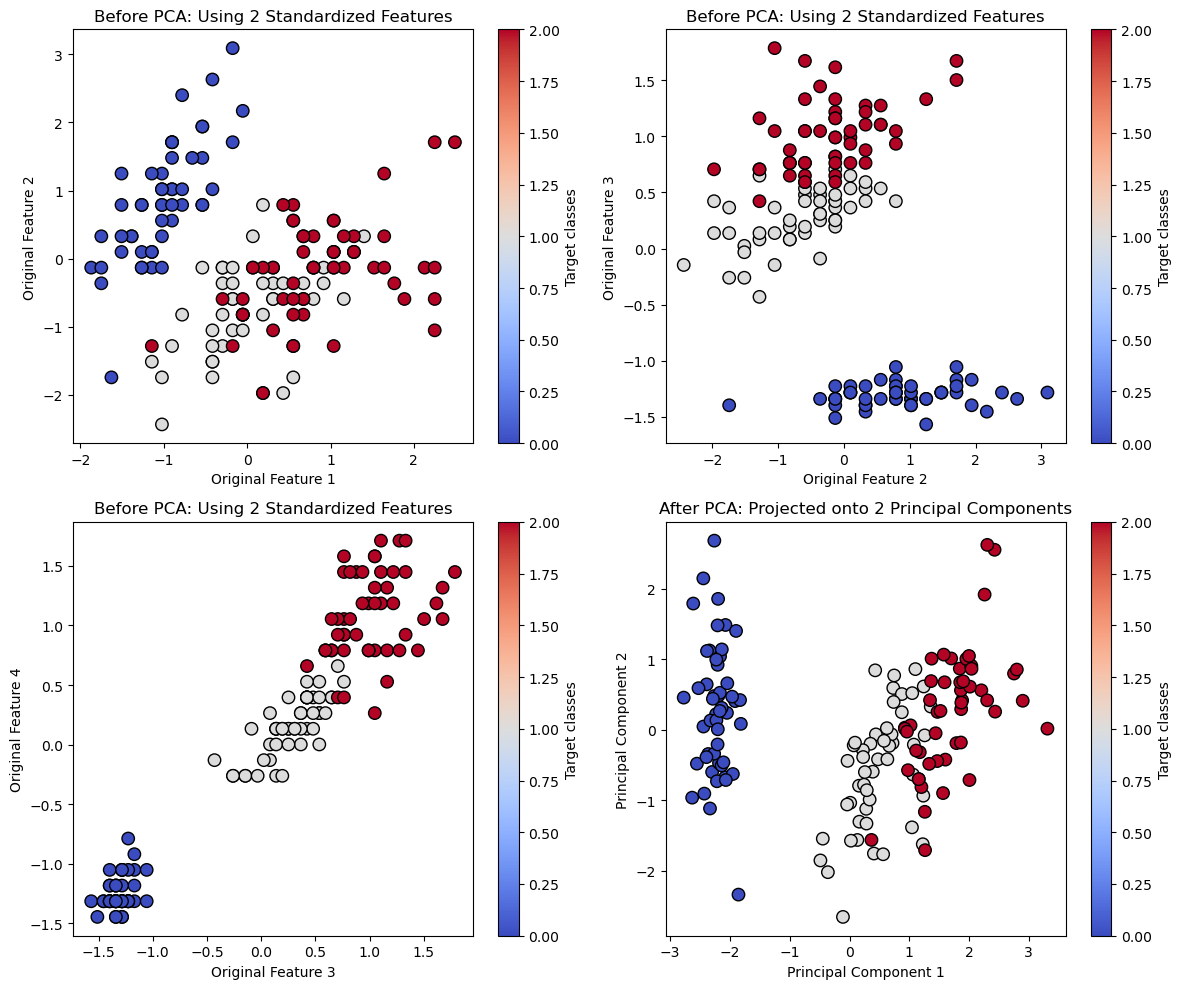

In [4]:
y_numeric = pd.factorize(y)[0]

plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_numeric, cmap='coolwarm', edgecolor='k', s=80)
plt.xlabel('Original Feature 1')
plt.ylabel('Original Feature 2')
plt.title('Before PCA: Using 2 Standardized Features')
plt.colorbar(label='Target classes')

plt.subplot(2, 2, 2)
plt.scatter(X_scaled[:, 1], X_scaled[:, 2], c=y_numeric, cmap='coolwarm', edgecolor='k', s=80)
plt.xlabel('Original Feature 2')
plt.ylabel('Original Feature 3')
plt.title('Before PCA: Using 2 Standardized Features')
plt.colorbar(label='Target classes')

plt.subplot(2, 2, 3)
plt.scatter(X_scaled[:, 2], X_scaled[:, 3], c=y_numeric, cmap='coolwarm', edgecolor='k', s=80)
plt.xlabel('Original Feature 3')
plt.ylabel('Original Feature 4')
plt.title('Before PCA: Using 2 Standardized Features')
plt.colorbar(label='Target classes')

plt.subplot(2, 2, 4)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_numeric, cmap='coolwarm', edgecolor='k', s=80)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('After PCA: Projected onto 2 Principal Components')
plt.colorbar(label='Target classes')

plt.tight_layout()
plt.show()


- Before PCA: Each shows the original standardized data plotted using two features. There is no guarantee of clear separation between classes as these are raw input dimensions.
- After PCA: This displays the transformed data using the top 2 principal components. These new components capture the maximum variance often showing better class separation and structure making it easier to analyze or model.


### Logistic Regression
- We split the data into 70% training and 30% testing sets.
- We train a logistic regression model on the reduced training data and predict iris labels on the test set.

In [19]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.3, random_state=42, stratify=y)

# print("Train shape:", X_train.shape)
# print("Test shape:", X_test.shape)
# print(y_test)


model = LogisticRegression(multi_class="multinomial", solver="lbfgs", max_iter=200)

start = time.time()
model.fit(X_train, y_train)
end = time.time()
t_train_pca = end - start

y_pred = model.predict(X_test)
acc_pca = accuracy_score(y_test, y_pred)
cm_pca = confusion_matrix(y_test, y_pred)
# print(cm_pca)


### Evaluation

The confusion matrix compares actual vs predicted labels. This makes it easy to see where predictions were correct or wrong.

In [20]:
# Train-test split
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)


model = LogisticRegression(multi_class="multinomial", solver="lbfgs", max_iter=200)

start = time.time()
model.fit(X_tr, y_tr)
end = time.time()
t_train_raw = end - start

y_pred = model.predict(X_te)
acc_raw = accuracy_score(y_te, y_pred)
cm_raw = confusion_matrix(y_te, y_pred)
# print(cm_raw)


                       Raw        PCA
----------------------------------------
       Test Accuracy   93.33%     88.89%
   Training time (s)   0.0219     0.0070


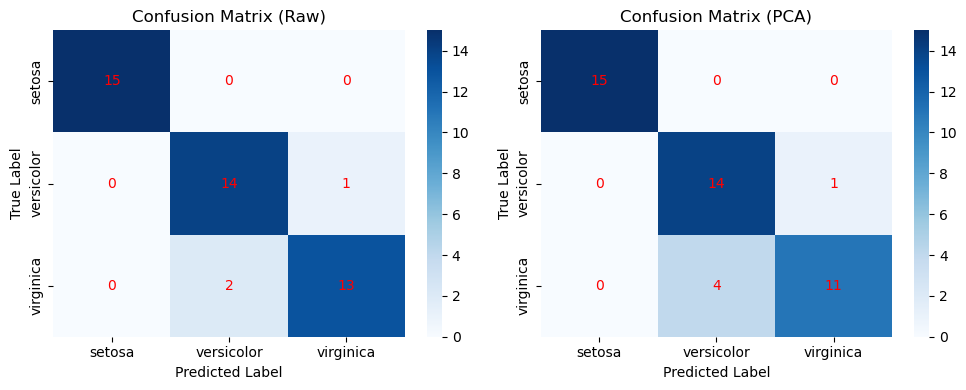

In [21]:
print(f'{" ":>20s}   Raw        PCA')
print('-' * 40)
print(f'{"Test Accuracy":>20s}   {acc_raw:.2%}     {acc_pca:.2%}')
print(f'{"Training time (s)":>20s}   {t_train_raw:.4f}     {t_train_pca:.4f}')

plt.figure(figsize=(10,4))

plt.subplot(1, 2, 1)
ax = sns.heatmap(cm_raw, cmap='Blues', xticklabels=['setosa', 'versicolor', 'virginica'], yticklabels=['setosa', 'versicolor', 'virginica'])
# manual annotations
for i in range(cm_raw.shape[0]):
    for j in range(cm_raw.shape[1]):
        ax.text(j + 0.5, i + 0.5, str(cm_raw[i, j]),
                ha='center', va='center', color='red')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Raw)')

plt.subplot(1, 2, 2)
ax = sns.heatmap(cm_pca, cmap='Blues', xticklabels=['setosa', 'versicolor', 'virginica'], yticklabels=['setosa', 'versicolor', 'virginica'])
# manual annotations
for i in range(cm_pca.shape[0]):
    for j in range(cm_pca.shape[1]):
        ax.text(j + 0.5, i + 0.5, str(cm_pca[i, j]),
                ha='center', va='center', color='red')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (PCA)')

plt.tight_layout()
plt.show()


**The point is to pack up highly correlated features in preprocessing stage.**